# Calculating 850-250 hPa Wind Shear

Importing Packages

In [1]:
!pip install cartopy

import pandas as pd
import numpy as np
import requests
import os
from pathlib import Path
import xarray as xr
import warnings
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 14.2 MB/s eta 0:00:00


### Calculating 850-250 hPa Wind Shear From the Pressure Level Subsets and Combining into One .nc File with SBCAPE

In [ ]:
pres_lvl_path = Path("/home/scratch/lmoeller/GEFSv12_ref_483/pres_lvl_nc")
cape_path = Path("/home/scratch/lmoeller/GEFSv12_ref_483/sbcape_nc")
output_path = Path("/home/scratch/lmoeller/GEFSv12_ref_483/cape_shear_nc")

def process_date(dtime):
    yr = dtime.year
    mo = dtime.month

    date_str = f"{yr}{mo:02d}{dtime.day:02d}00"

    pres_file = pres_lvl_path / str(yr) / f"{mo:02d}" / f"gefs_c00_{date_str}_pres_subset.nc"
    cape_file = cape_path / str(yr) / f"{mo:02d}" / f"gefs_c00_{date_str}_sbcape_subset.nc"

    out_folder = output_path / str(yr) / f"{mo:02d}"
    out_folder.mkdir(parents=True, exist_ok=True)

    out_file = out_folder / f"gefs_c00_{date_str}_cape_shear_subset.nc"

    pres_ds = xr.open_dataset(pres_file)
    cape_ds = xr.open_dataset(cape_file).load()

    # IMPORTANT: Since every other grid point becomes nan at 700 hPa and above, we need to interpolate
    u_filled = pres_ds['u'].interpolate_na(dim='longitude', method='linear', fill_value="extrapolate")
    u_filled = u_filled.interpolate_na(dim='latitude', method='linear', fill_value="extrapolate")

    v_filled = pres_ds['v'].interpolate_na(dim='longitude', method='linear', fill_value="extrapolate")
    v_filled = v_filled.interpolate_na(dim='latitude', method='linear', fill_value="extrapolate")

    u850 = u_filled.sel(isobaricInhPa=850)
    u250 = u_filled.sel(isobaricInhPa=250)

    v850 = v_filled.sel(isobaricInhPa=850)
    v250 = v_filled.sel(isobaricInhPa=250)

    shear = np.sqrt((u250 - u850)**2 + (v250 - v850)**2)

    shear = shear.rename("shear_850_250")
    shear.attrs["units"] = "m s-1"

    cape_ds["shear_850_250"] = shear

    encoding = {"shear_850_250": {"zlib": True, "complevel": 5}}
    cape_ds.to_netcdf(out_file, encoding=encoding)

    print(f"Saved {out_file.name}  ({out_file.stat().st_size / (1024**2):.1f} MB)")

    pres_ds.close()
    cape_ds.close()


def main():
    for year in range(2001, 2020):
        dates = pd.date_range(start=f"{year}-05-01", end=f"{year}-05-31", freq="1D")

        for d in dates:
            process_date(d)


if __name__ == "__main__":
    main()

### Plotting to Make Sure the Calculation Produced a Reasonable Result

Let's use one sample file (download here):

https://niuits-my.sharepoint.com/:f:/g/personal/z1953922_students_niu_edu/IgDIvDhAaF3IRo4u68N8C-RDAfaE5qGU1isAwmaEL2TF7iw?e=luqlUu

In [2]:
ds = xr.open_dataset("gefs_c00_2000050100_cape_shear_subset.nc")
ds

/tmp/ipykernel_48911/4227547001.py:1: FutureWarning: In a future version, xarray will not decode the variable 'step' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset("gefs_c00_2000050100_cape_shear_subset.nc")


<xarray.Dataset> Size: 6MB
Dimensions:        (step: 40, latitude: 113, longitude: 169)
Coordinates:
  * step           (step) timedelta64[ns] 320B 0 days 06:00:00 ... 5 days 03:...
  * latitude       (latitude) float64 904B 51.0 50.75 50.5 ... 23.5 23.25 23.0
  * longitude      (longitude) float64 1kB -107.0 -106.8 -106.5 ... -65.25 -65.0
    number         int64 8B ...
    time           datetime64[ns] 8B ...
    surface        float64 8B ...
    valid_time     (step) datetime64[ns] 320B ...
Data variables:
    cape           (step, latitude, longitude) float32 3MB ...
    shear_850_250  (step, latitude, longitude) float32 3MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          2
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-04-11T09:31 GRIB to CDM+CF via cfgrib-0.9.1...

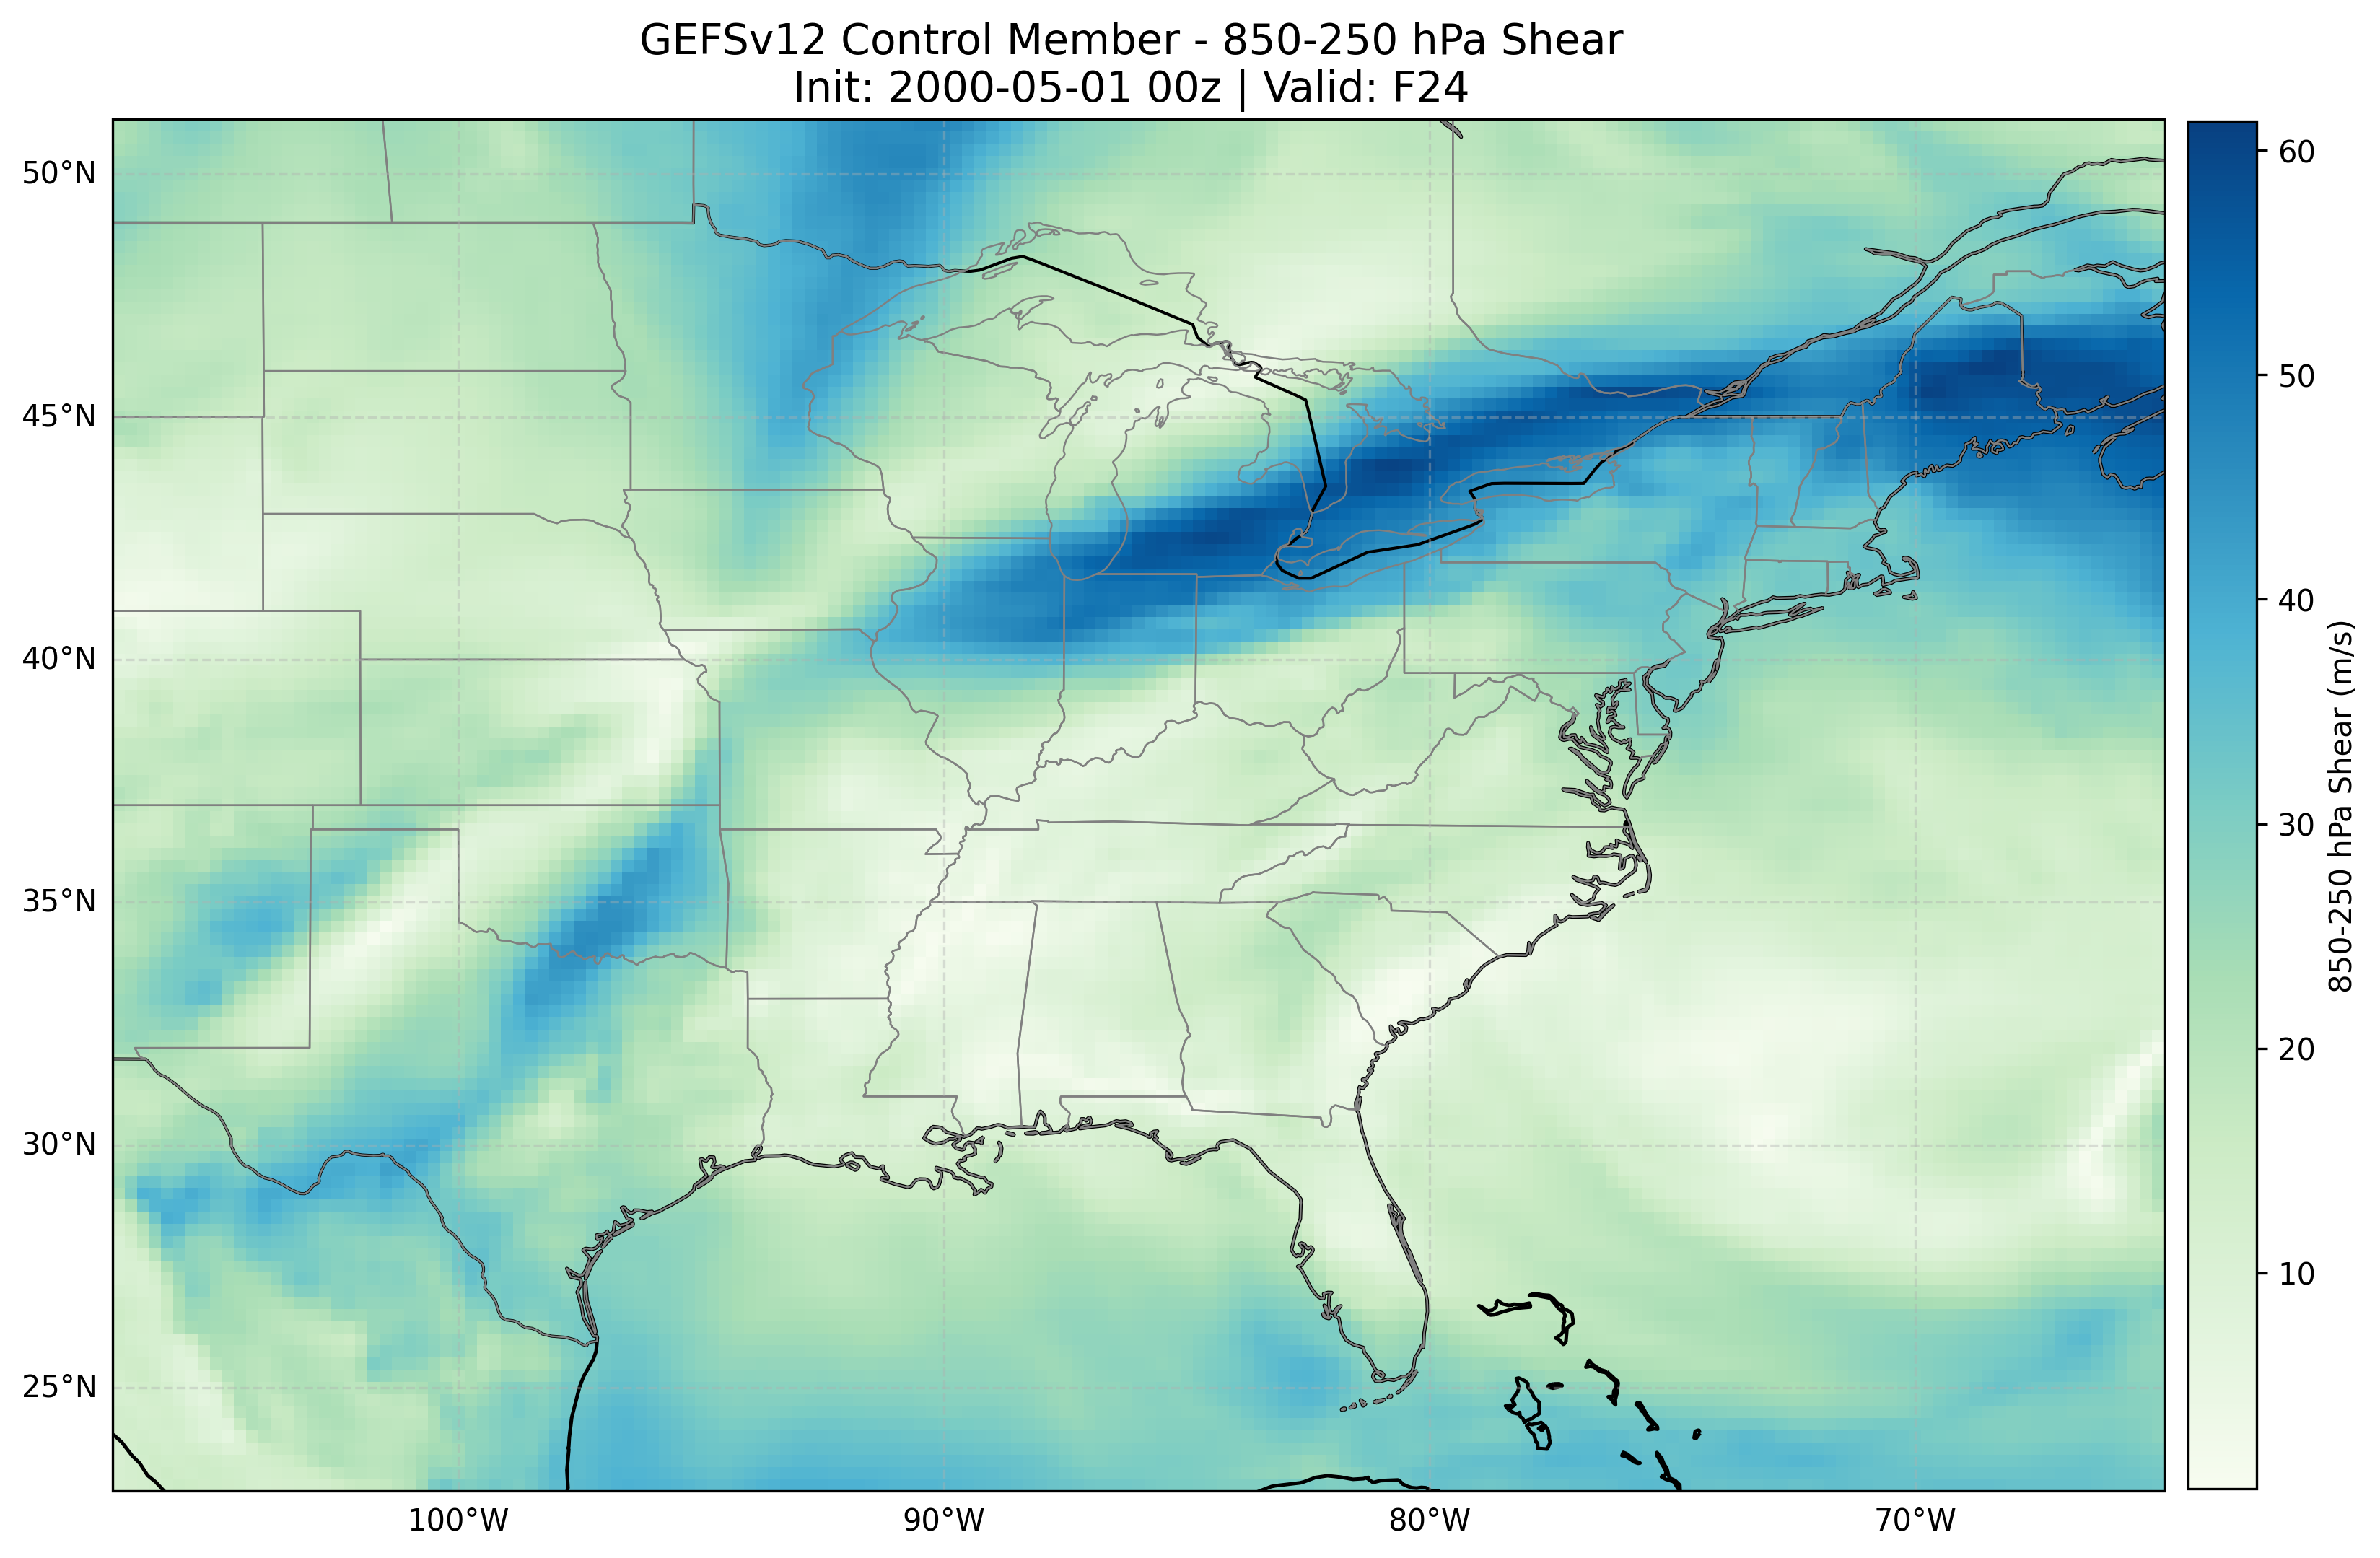

In [5]:
step_hours = 24

shear = ds['shear_850_250'].sel(step=pd.Timedelta(hours=step_hours))

fig = plt.figure(figsize=(12, 9), dpi=300)
ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree())

contour = shear.plot.pcolormesh(ax=ax, cmap='GnBu', transform=ccrs.PlateCarree(),
                          cbar_kwargs={'label': '850-250 hPa Shear (m/s)', 'shrink': 0.726, 'pad': 0.01})

ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=1.2)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=1.0)
ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.6, edgecolor='gray')

gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.4)
gl.top_labels = False
gl.right_labels = False

plt.title(f"GEFSv12 Control Member - 850-250 hPa Shear \n"
          f"Init: 2000-05-01 00z | Valid: F{step_hours} ", fontsize=14)

plt.tight_layout()
plt.show()